In [195]:
from photutils.datasets import load_simulated_hst_star_image
from photutils.datasets import make_noise_image
import matplotlib.pyplot as plt
from astropy.visualization import simple_norm
from photutils.datasets import (load_simulated_hst_star_image,make_noise_image)
from photutils.detection import find_peaks
from astropy.table import Table
from astropy.stats import sigma_clipped_stats
from astropy.nddata import NDData
from photutils.psf import extract_stars
import matplotlib.pyplot as plt
from astropy.visualization import simple_norm
from photutils.psf import EPSFBuilder
from astropy.io import fits
import numpy as np

In [206]:
#Load data
data = fits.getdata("/Users/niklasviebig/Desktop/Astro-3/science_36UMa_final.fits", ext=0)

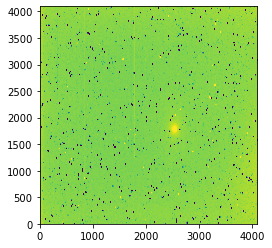

In [207]:
#Plot image
norm = simple_norm(data, 'sqrt', percent=99.0)
plt.imshow(data, norm=norm, origin='lower', cmap='viridis')

In [208]:
# use the find_peaks() function to identify the stars and their initial positions
#(threshold value to 500.0 to select only the brightest stars)
peaks_tbl = find_peaks(data, threshold=900)  
peaks_tbl['peak_value'].info.format = '%.8g'  # for consistent table output  
print(peaks_tbl)  

x_peak y_peak peak_value
------ ------ ----------
   428     37  1169.6447
  2887     93  1145.2173
  2889    100  1118.8109
  2886    101  1301.0243
  3137    140  905.40033
  1421    316  1411.8562
   726    348  2464.4451
  3710    363  3024.6202
  1514    500  27617.772
  3460    543  1232.0413
   ...    ...        ...
  2676   3683  1194.8122
  2674   3687  1341.3327
  2670   3688  1008.1419
  3295   3761  16637.851
  1752   3773  1069.8974
  1756   3776  1458.7582
  1754   3780  943.71407
  2408   3908  3183.4449
   913   4040  7058.0812
   333   4092  2301.2939
   333   4094  2398.4791
Length = 101 rows


In [209]:
#extract cutouts of the stars using the extract_stars() function
#We plan to extract 25 x 25 pixel cutouts of our selected stars, 
#so let’s explicitly exclude stars that are too close to the image boundaries 
#(because they cannot be extracted):
size = 50 #25
hsize = (size - 1) / 2
x = peaks_tbl['x_peak']  
y = peaks_tbl['y_peak']  
mask = ((x > hsize) & (x < (data.shape[1] -1 - hsize)) & (y > hsize) & (y < (data.shape[0] -1 - hsize)))  

In [210]:
#create the table of good star positions:
stars_tbl = Table()
stars_tbl['x'] = x[mask]  
stars_tbl['y'] = y[mask]  

In [211]:
#extract_stars() function requires the input data as an NDData object
nddata = NDData(data=data)  

In [255]:
#ready to create our star cutouts using the extract_stars()
stars = extract_stars(nddata, stars_tbl, size=25)  
type(stars)

photutils.psf.epsf_stars.EPSFStars

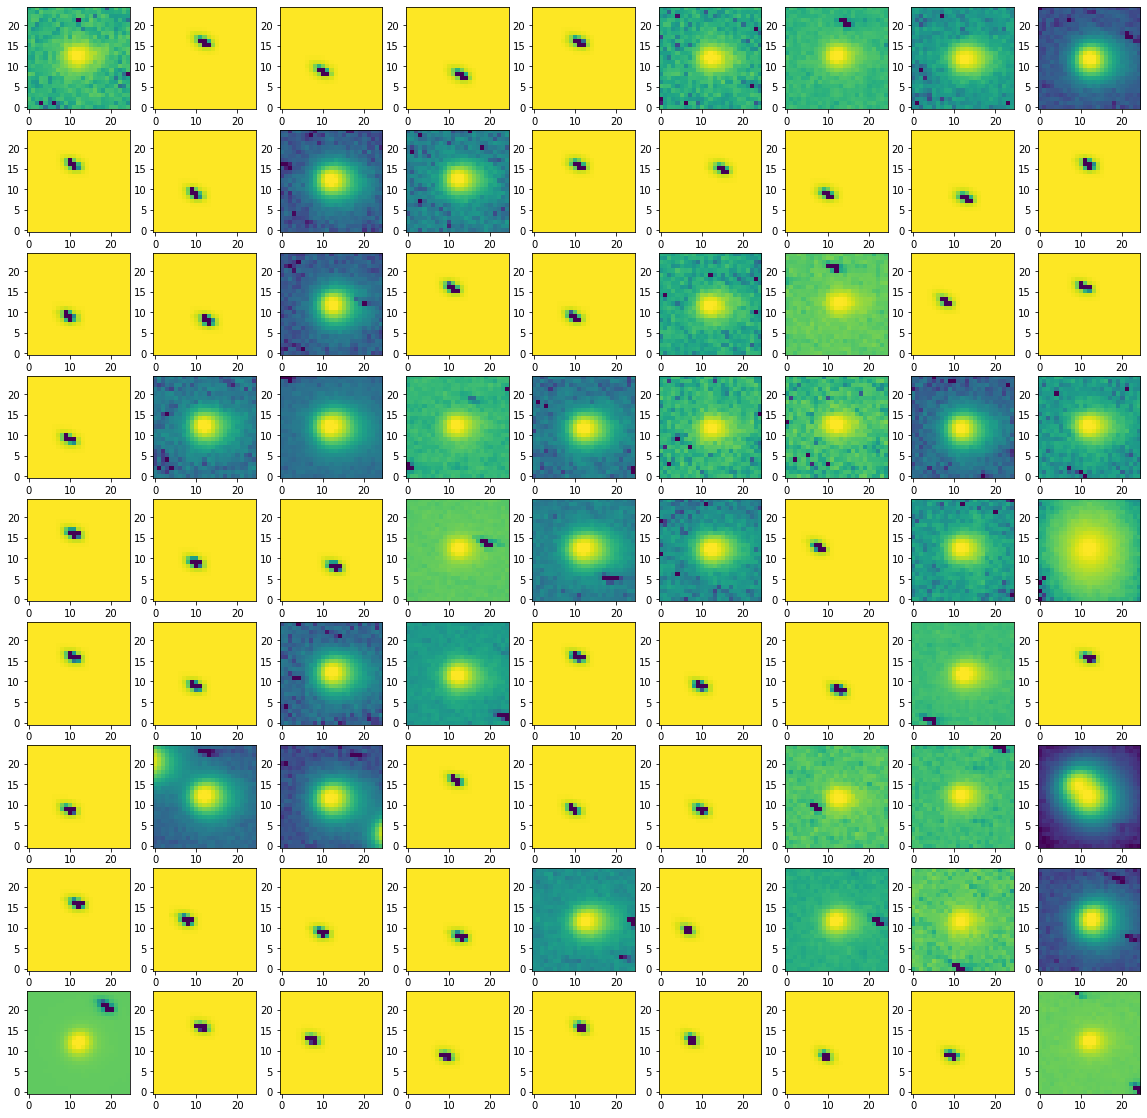

In [213]:
#The function returns a EPSFStars object containing the cutouts of our selected stars. 
#The function extracted 403 stars, from which we’ll build our ePSF. Let’s show the first 25 of them
nrows = 9
ncols = 9
fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 20),squeeze=True)
ax = ax.ravel()
for i in range(nrows * ncols):
    norm = simple_norm(stars[i], 'log', percent=99.0)
    ax[i].imshow(stars[i], norm=norm, origin='lower', cmap='viridis')

In [277]:
list_star = []
will_ich = [0,
            5,
            6,
            7,
            8,
            11,
            12,
            20,
            23,
            24,
            28,
            29,
            30,
            31,
            32,
            33,
            34,
            35,
            39,
            40,41,43,44,47,48,52,55,56,60,61,62,67,69,71,72,73,74,82]

for i in (will_ich):
    list_star.append(photutils.psf.EPSFStar(data = stars[i].data,weights = stars[i].weights,
                                            cutout_center = stars[i].cutout_center,
                                            origin = stars[i].origin,
                                            wcs_large = stars[i].wcs_large,
                                            id_label = stars[i].id_label))
    
stars_new = photutils.psf.EPSFStars(list_star)

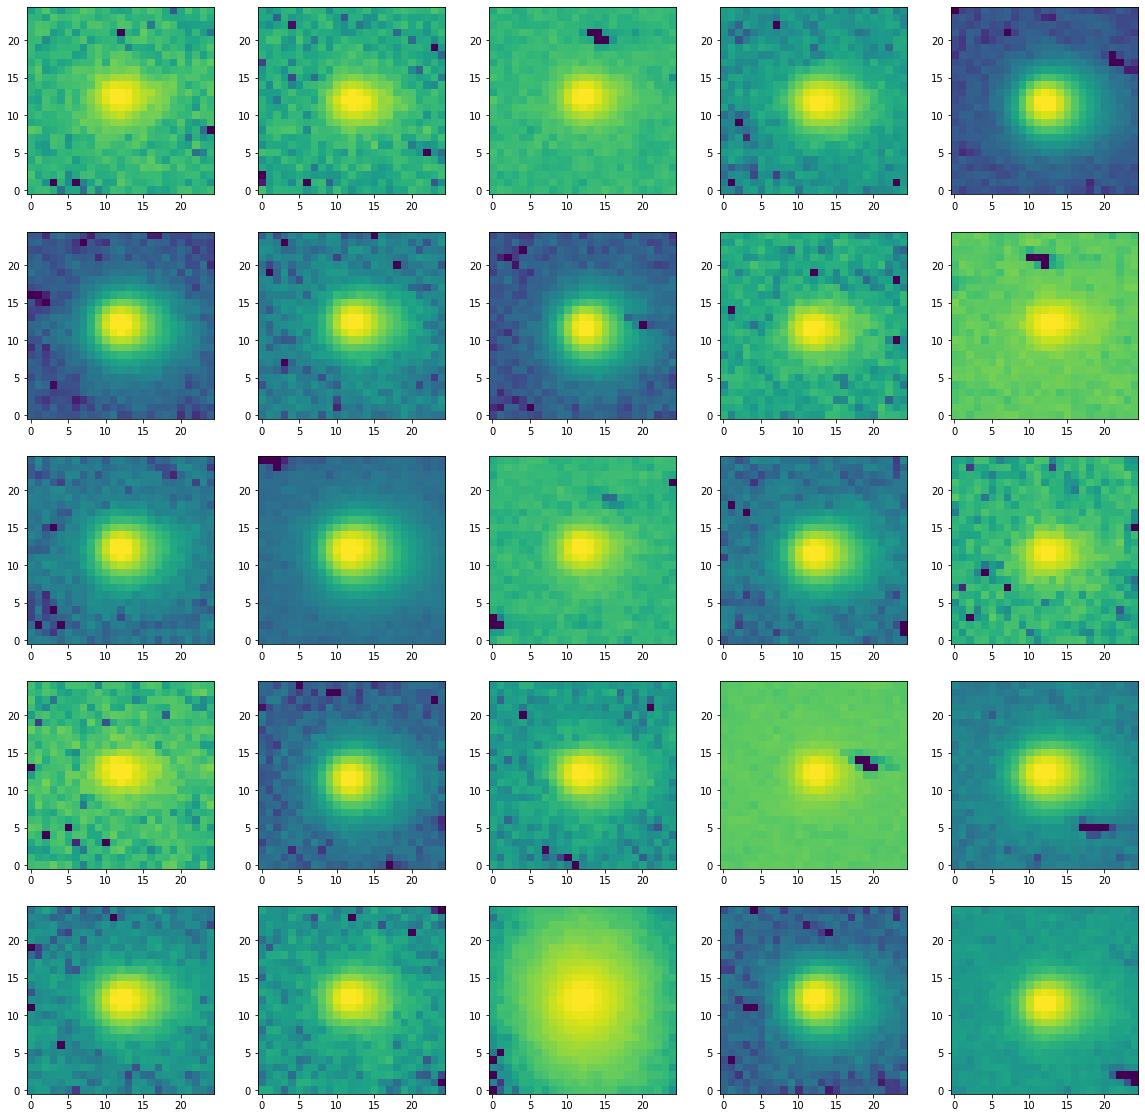

In [278]:
nrows = 5
ncols = 5
fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 20),squeeze=True)
ax = ax.ravel()
for i in range(nrows * ncols):
    norm = simple_norm(stars_new[i], 'log', percent=99.0)
    ax[i].imshow(stars_new[i], norm=norm, origin='lower', cmap='viridis')

In [279]:
#with the star cutouts in hand, we are ready to construct the ePSF with the EPSFBuilder class
#We’ll create an ePSF with an oversampling factor of 4.0. 
#Here we limit the maximum number of iterations to 3 (to limit it’s run time), 
#but in practice one should use about 10 or more iterations. 
#The EPSFBuilder class has many other options to control the ePSF build process, 
#including changing the centering function, the smoothing kernel,
#and the centering accuracy. Please see the EPSFBuilder documentation for further details.
epsf_builder = EPSFBuilder(oversampling=4, maxiters=15,progress_bar=True)  
epsf, fitted_stars = epsf_builder(stars_new)  

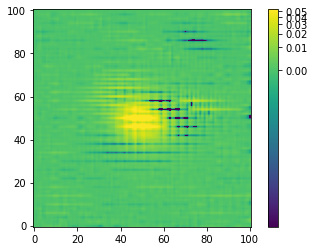

In [281]:
#The returned values are the ePSF, 
#as an EPSFModel object, and our input stars fitted with the constructed ePSF, 
#as a new EPSFStars object with fitted star positions and fluxes.
norm = simple_norm(epsf.data, 'log', percent=99.0)
plt.imshow(epsf.data, norm=norm, origin='lower', cmap='viridis')
plt.colorbar()

In [288]:
fits.writeto("/Users/niklasviebig/Desktop/Astro-3/psf.fits",epsf.data, overwrite=True)